# Notebook 04 — Forecast

This notebook builds two baseline time-series models for PM2.5 at Cerro Navia,
the highest-pollution station in the dataset, to explore whether air quality
can be predicted from temporal patterns alone.

## Research questions
- Is there a measurable long-term trend in PM2.5 at Cerro Navia?
- Can a simple model capture the seasonal cycle?

## Station choice
Cerro Navia was selected because it has complete data from January 2020,
is consistently among the highest-pollution stations in the RM, and its
strong seasonal signal makes the forecasting results easier to interpret.

## Models built
- **7-day rolling average:** a naive baseline that predicts tomorrow based
  on the average of the previous 7 days.
- **Linear regression:** uses two temporal features (`time_idx` and
  `day_of_year`) to model long-term trend and seasonality simultaneously.

## Data source
Clean daily data from `data/interim/air_quality_daily.parquet`,
produced by `02_clean.ipynb`. Filtered to Cerro Navia: 2,135 records,
2020-01-01 to 2025-12-31, zero missing values.


In [1]:
# Imports
import pandas as pd
import numpy as no
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from pathlib import Path

INTERIM_DIR = Path('../data/interim')
air = pd.read_parquet(INTERIM_DIR / 'air_quality_daily.parquet')

# Filter to Cerro Navia only
station = 'Cerro Navia'
air_station = air[air['station'] == station].copy().sort_values('date').reset_index(drop=True)

print(f'Records for {station}: {len(air_station)}')
print(f'Date range: {air_station["date"].min()} to {air_station["date"].max()}')
print(f'Missing pm25_mean: {air_station["pm25_mean"].isna().sum()}')

Records for Cerro Navia: 2135
Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00
Missing pm25_mean: 0


In [2]:
# 7-day rolling average baseline
air_station['rolling_7d'] = air_station['pm25_mean'].rolling(window=7, center=False).mean()

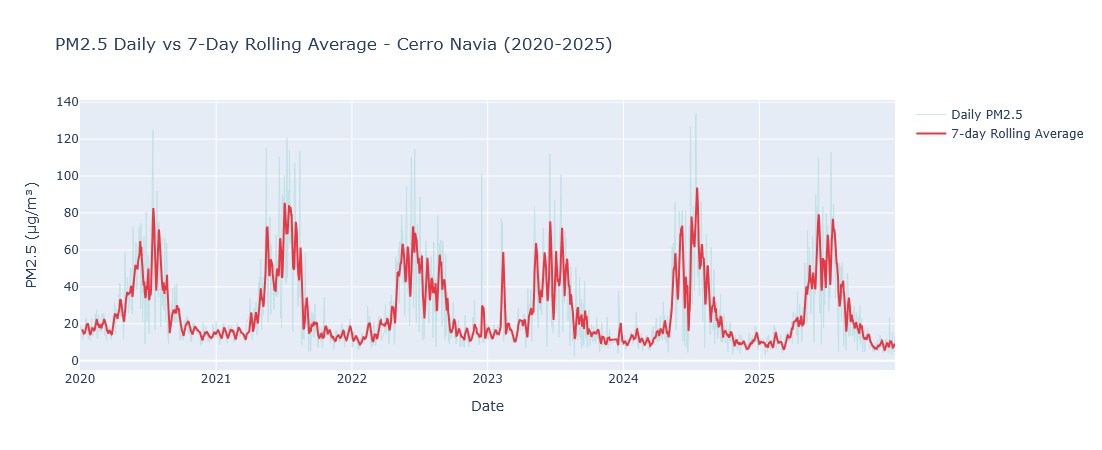

In [3]:
# Plot actual vs rolling average
fig = go.Figure()

fig.add_trace(go.Scatter(
    x= air_station['date'],
    y= air_station['pm25_mean'],
    name= 'Daily PM2.5',
    line= dict(color='#a8dadc', width=1),
    opacity=0.6
))

fig.add_trace(go.Scatter(
    x= air_station['date'],
    y= air_station['rolling_7d'],
    name= '7-day Rolling Average',
    line= dict(color= '#e63945', width=2)
))

fig.update_layout(
    title= f'PM2.5 Daily vs 7-Day Rolling Average - {station} (2020-2025)',
    xaxis_title= 'Date',
    yaxis_title= 'PM2.5 (µg/m³)',
    height= 450
)

fig.write_html('../figures/rolling_average.html')
fig.show()

In [4]:
# Create temporal features
air_station['day_of_year'] = air_station['date'].dt.dayofyear

# Create numeric index for regression
air_station['time_idx'] = (air_station['date'] - air_station['date'].min()).dt.days

In [5]:
# Fit linear regression with temporal features
X = air_station[['time_idx', 'day_of_year']].dropna()
y = air_station.loc[X.index, 'pm25_mean']

model = LinearRegression()
model.fit(X, y)

air_station['trend_full'] = model.predict(air_station[['time_idx', 'day_of_year']])

print(f'R²: {model.score(X, y):.4f}')
print(f'Coefficients:')
print(f'    time_idx (overall trend): {model.coef_[0]:.4f} µg/m³ per day')
print(f'    day_of_year (seasonal):   {model.coef_[1]:.4f} µg/m³ per day of year')

R²: 0.0077
Coefficients:
    time_idx (overall trend): -0.0024 µg/m³ per day
    day_of_year (seasonal):   -0.0080 µg/m³ per day of year


## Time-Seties Forecast Model - Cerro Navia

This notebook builds two baseline forecasting models for PM2.5 at Cerro Navia, the highest-pollution station in the dataset.

### Baseline model: 7-day rolling average
The 7-day rolling average smooths daily noise while follwing seasonal trend. On day N, the model predicts the average of the previous 7 days. This is a legitimate forecasting baseline because it is simple, interpretable, and requires no assumptions about the underlying data distribution.

Its main limitation is that it vannot anticipate sudden pollution episodes such as wildfires o cold snaps, because it only looks backwards.

### Trend mode: linear regression with temporal features
A linear regression using two features: 'time_idx' (days since the start of the dataset, capturing lon-term trend) and 'day_of_year' (capturing seasonally).

Results:
- R² = 0.0077: the model explains less than 1% of the variance in daily PM2.5.
- 'time_idx' coefficient = -0.0024 µg/m³ per day (~-0.88 µg/m³ per year): confirms the gradual improvement trend observed in the year-over-year analysis.
- 'day_of_year' coefficient = -0.0080: captures a weak seasonal signal, though linear regression cannot fully model the non-lineal seasonal cycle where PM2.5 rises theough winter and falls through summer.

### Why the R² is low and why that is honest
Daily PM2,5 is driven primarily by meteorological conditions: temperature inversions, wind speed, and precipitation. These are not captured in temporal features alone. A low  R² does not mean the model is wrong; it means that the time alone is not sufficient to explain air quality variation. The next step would be to include weather variables as predictors, which is beyond the scope of this project.


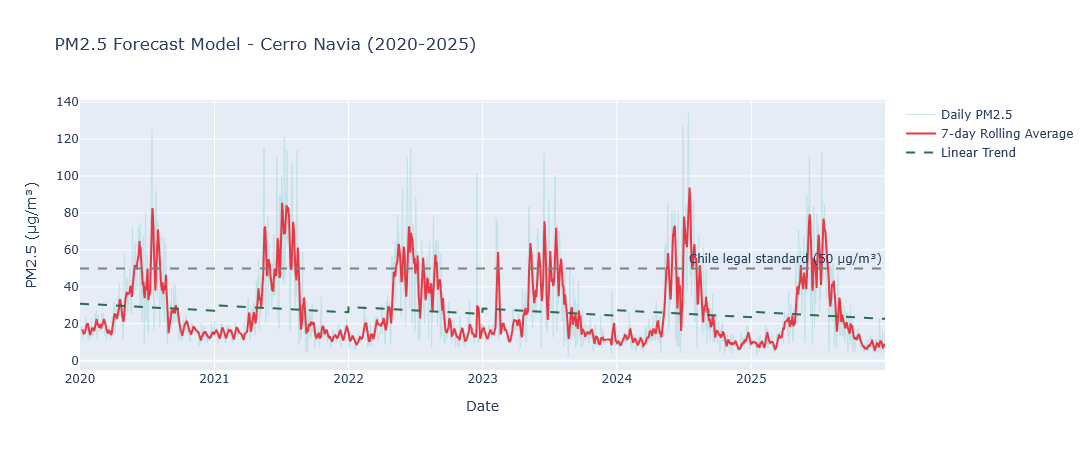

In [7]:
# Graph of real vs forecast
fig = go.Figure()

fig.add_trace(go.Scatter(
    x= air_station['date'],
    y= air_station['pm25_mean'],
    name= 'Daily PM2.5',
    line= dict(color='#a8dadc', width=1),
    opacity=0.6
))

fig.add_trace(go.Scatter(
    x= air_station['date'],
    y= air_station['rolling_7d'],
    name= '7-day Rolling Average',
    line= dict(color= '#e63945', width=2)
))


fig.add_trace(go.Scatter(
    x= air_station['date'],
    y= air_station['trend_full'],
    name= 'Linear Trend',
    line= dict(color= '#2d6a4f', width=2, dash='dash')
))

fig.add_hline(
    y=50,
    line_dash= 'dash',
    line_color= 'gray',
    annotation_text= 'Chile legal standard (50 µg/m³)',
    annotation_position= 'top right'
)

fig.update_layout(
    title= f'PM2.5 Forecast Model - {station} (2020-2025)',
    xaxis_title= 'Date',
    yaxis_title= 'PM2.5 (µg/m³)',
    height= 450
)

fig.write_html('../figures/pm25_forecast.html')
fig.show()

## Forecast Summary

Both models confirm the two main patterns identified in the analysis notebook:

- **Seasonal cycle:** PM2.5 peaks every winter (June-August) and drops
  every summer (December-February), driven by Santiago's temperature
  inversions. The 7-day rolling average follows this cycle closely.
- **Long-term improvement:** The linear trend line shows a gradual decline
  of approximately 0.88 µg/m³ per year over the 2020-2025 period.

The low R² (0.0077) is an honest result, not a failure. Daily PM2.5 is
driven primarily by meteorological conditions such as temperature inversions,
wind speed, and precipitation, none of which are captured in temporal
features alone. The natural next step would be to incorporate weather
variables as predictors, which is beyond the scope of this project.
